## Downscaling and moving windows
- Downscaling DTM rasters to 30m to have same-level scale with LST images 
- computing moving windows and study the correlations with LST depending on the size of the window.

In [1]:
!pip install rasterio


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\guada\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
lst_cropped_path = '../../datos-notebooks/0.LST/LST_cropped_celsius.tif'
dtm_path = '../../datos-notebooks/3.topography/dtm_mosaic.tif'

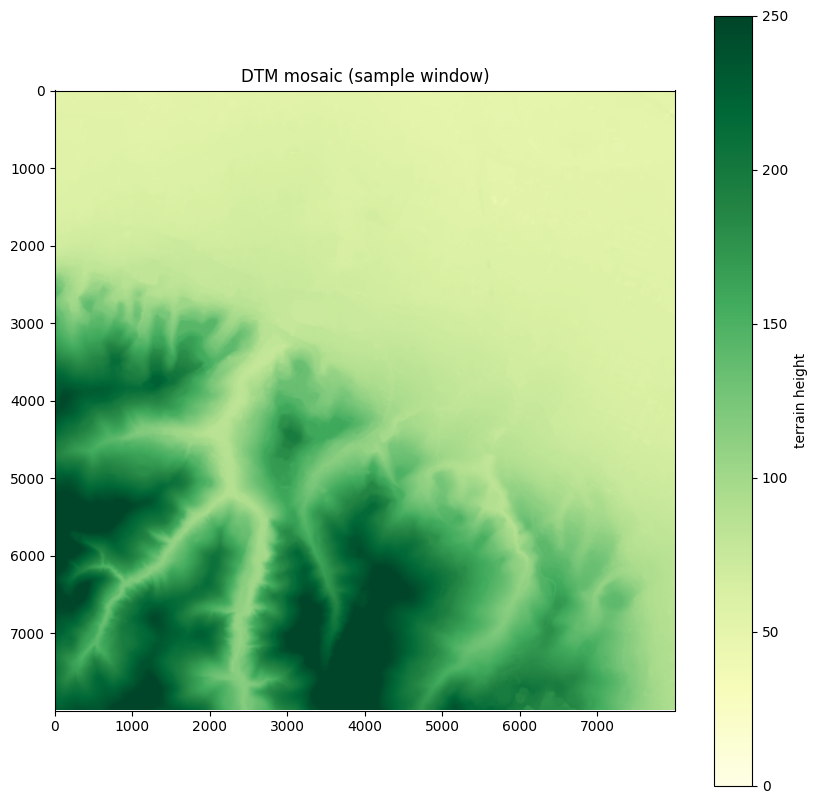

In [12]:
#print a window
import rasterio
import matplotlib.pyplot as plt

# --- Open mosaic ---
with rasterio.open(dtm_path) as src:
    # define a small window (row_start, row_stop, col_start, col_stop)
    window = rasterio.windows.Window(col_off=15000, row_off=13000, width=8000, height=8000)
    data = src.read(1, window=window)

    # get transform for plotting
    transform = src.window_transform(window)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10,10))
img = ax.imshow(data, cmap='YlGn', vmin=0, vmax=250,)
ax.set_title("DTM mosaic (sample window)")
plt.colorbar(img, ax=ax, label="terrain height")
plt.show()


Downscale to 30m and extract:
- mean elevation
- mean slope
- northness
- eastness


In [ ]:
import rasterio
from rasterio.enums import Resampling
from rasterio.warp import reproject
import numpy as np
import os

# Input paths
lst_cropped_path = '../../datos-notebooks/0.LST/LST_cropped_celsius.tif'
dtm_path = '../../datos-notebooks/3.topography/dtm_mosaic.tif'

# Output directory
output_dir = os.path.join(os.path.dirname(dtm_path), "dtm_pct_30m")
os.makedirs(output_dir, exist_ok=True)

with rasterio.open(lst_cropped_path) as lst_ref:
    lst_profile = lst_ref.profile
    lst_transform = lst_ref.transform
    lst_crs = lst_ref.crs
    lst_shape = (lst_ref.height, lst_ref.width)

with rasterio.open(dtm_path) as dtm_src:
    dtm_data = dtm_src.read(1)
    dtm_profile = dtm_src.profile

    # ✅ Force CRS if missing
    if dtm_src.crs is None:
        from rasterio.crs import CRS
        dtm_crs = CRS.from_epsg(7791)  # EPSG:7791 = POSGAR 2007 / Argentina 4 (por ejemplo)
    else:
        dtm_crs = dtm_src.crs

    dtm_resampled = np.empty(lst_shape, dtype=np.float32)

    reproject(
        source=dtm_data,
        destination=dtm_resampled,
        src_transform=dtm_src.transform,
        src_crs=dtm_crs,            # ✅ use the CRS we defined
        dst_transform=lst_transform,
        dst_crs=lst_crs,
        resampling=Resampling.average
    )



In [ ]:

# Extend borders before computing gradients ---
# Extend array by one pixel in each direction, repeating edge values
dtm_pad = np.pad(dtm_resampled, pad_width=1, mode='edge')

# Pixel size (xres, yres)
xres = lst_transform.a
yres = -lst_transform.e  # usually negative

# Compute gradients on padded array
dz_dy, dz_dx = np.gradient(dtm_pad, yres, xres)

# Remove padding to restore original shape
dz_dy = dz_dy[1:-1, 1:-1]
dz_dx = dz_dx[1:-1, 1:-1]

# Compute slope and aspect ---
# Slope in radians
slope = np.arctan(np.sqrt(dz_dx**2 + dz_dy**2))
# Aspect (0 = North)
aspect = np.arctan2(dz_dx, -dz_dy)
aspect = np.where(aspect < 0, 2 * np.pi + aspect, aspect)

# Compute northness and eastness ---
northness = np.cos(aspect)
eastness = np.sin(aspect)

# Save rasters ---
def save_raster(filename, array):
    profile = lst_profile.copy()
    profile.update(dtype=rasterio.float32, count=1, compress='lzw')
    with rasterio.open(os.path.join(output_dir, filename), 'w', **profile) as dst:
        dst.write(array.astype(np.float32), 1)

save_raster('elev_mean.tif', dtm_resampled)
save_raster('slope_mean.tif', np.degrees(slope))  # degrees
save_raster('northness.tif', northness)
save_raster('eastness.tif', eastness)

print("✅ Finished. Files saved as elev_mean.tif, slope_mean.tif, northness.tif, eastness.tif")

✅ Finished. Files saved as elev_mean.tif, slope_mean.tif, northness.tif, eastness.tif


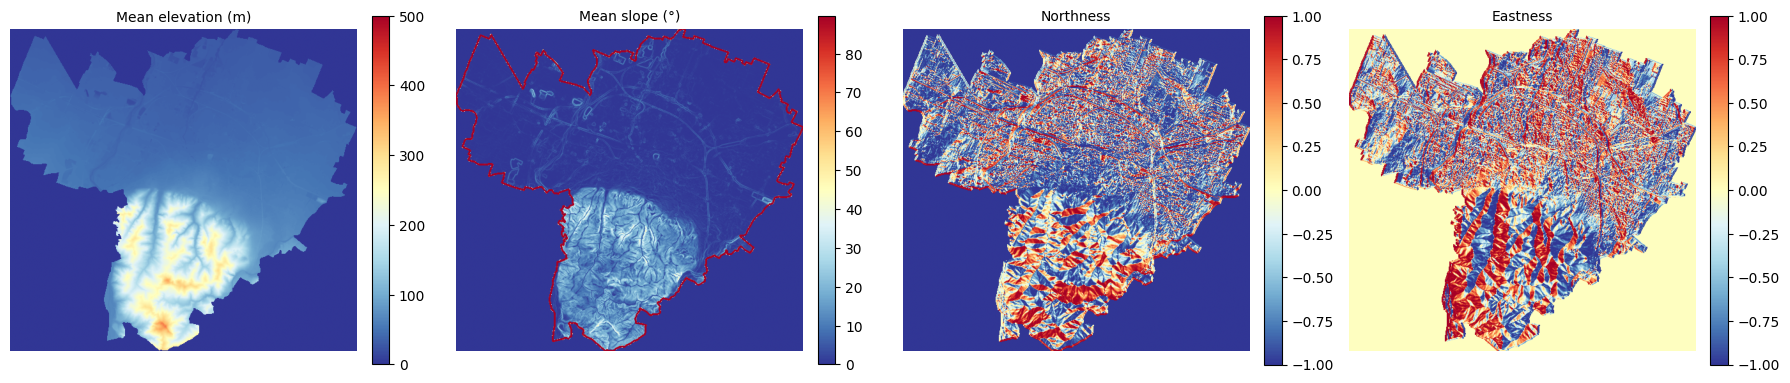

In [29]:

files = {
    "Mean elevation (m)": os.path.join(output_dir, "elev_mean.tif"),
    "Mean slope (°)": os.path.join(output_dir, "slope_mean.tif"),
    "Northness": os.path.join(output_dir, "northness.tif"),
    "Eastness": os.path.join(output_dir, "eastness.tif")
}

# Create 1x4 subplot grid
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, (title, path) in zip(axes, files.items()):
    with rasterio.open(path) as src:
        data = src.read(1)
        data = np.where(np.isfinite(data), data, np.nan)  # mask invalid values

    # Choose colormap
    cmap = 'terrain' if 'Elevación' in title else 'RdYlBu_r'

    # Set vmin/vmax only for Elevación
    if 'elevation' in title:
        im = ax.imshow(data, cmap=cmap, vmin=0, vmax=500)  
    else:
        im = ax.imshow(data, cmap=cmap)

    ax.set_title(title, fontsize=10)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


moving windows

In [57]:
import rasterio
import numpy as np
import os
from scipy.ndimage import uniform_filter

files = {
    "elev_mean": os.path.join(output_dir, "elev_mean.tif"),
    "slope_mean": os.path.join(output_dir, "slope_mean.tif"),
    "northness": os.path.join(output_dir, "northness.tif"),
    "eastness": os.path.join(output_dir, "eastness.tif")
}

# --- Function to compute moving window average ---
def moving_window_mean(array, size):
    """Compute mean in a square window of given size around each pixel."""
    if size == 1:
        return array  # window of 1 = original pixel
    return uniform_filter(array, size=size, mode='nearest')

# --- Process each raster and create subfolder ---
for var_name, path in files.items():
    var_dir = os.path.join(output_dir, var_name)
    os.makedirs(var_dir, exist_ok=True)  # create folder for each variable

    with rasterio.open(path) as src:
        data = src.read(1)
        profile = src.profile

    for w in range(1, 301):  # window sizes
        avg_window = moving_window_mean(data, w)
        out_name = f"{var_name}_win{w}.tif"
        out_path = os.path.join(var_dir, out_name)
        profile.update(dtype=rasterio.float32, compress='lzw')
        with rasterio.open(out_path, 'w', **profile) as dst:
            dst.write(avg_window.astype(np.float32), 1)

# --- Compute relative elevation (micro-relief) ---
rel_dir = os.path.join(output_dir, "rel_elev")
os.makedirs(rel_dir, exist_ok=True)

with rasterio.open(files['elev_mean']) as src:
    elev = src.read(1)
    profile = src.profile

for w in range(1, 301):
    elev_mean_window = moving_window_mean(elev, w)
    rel_elev = elev - elev_mean_window
    out_name = f"rel_elev_win{w}.tif"
    out_path = os.path.join(rel_dir, out_name)
    profile.update(dtype=rasterio.float32, compress='lzw')
    with rasterio.open(out_path, 'w', **profile) as dst:
        dst.write(rel_elev.astype(np.float32), 1)

print("✅ Finished. All variables saved in separate folders by variable")


✅ Finished. All variables saved in separate folders by variable


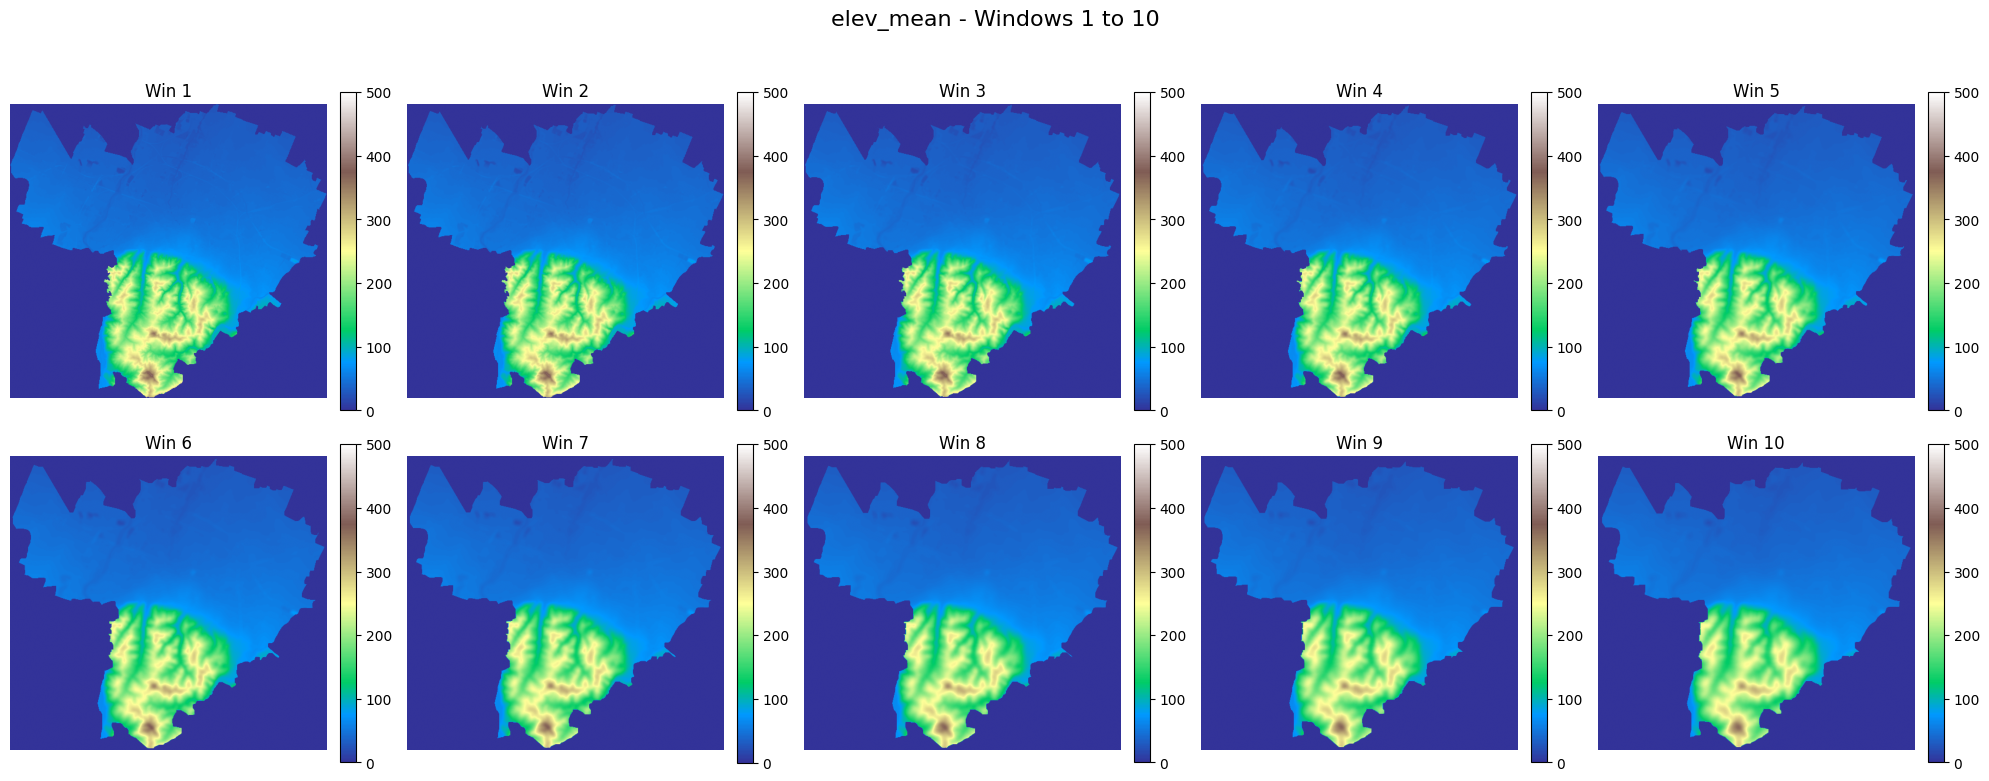

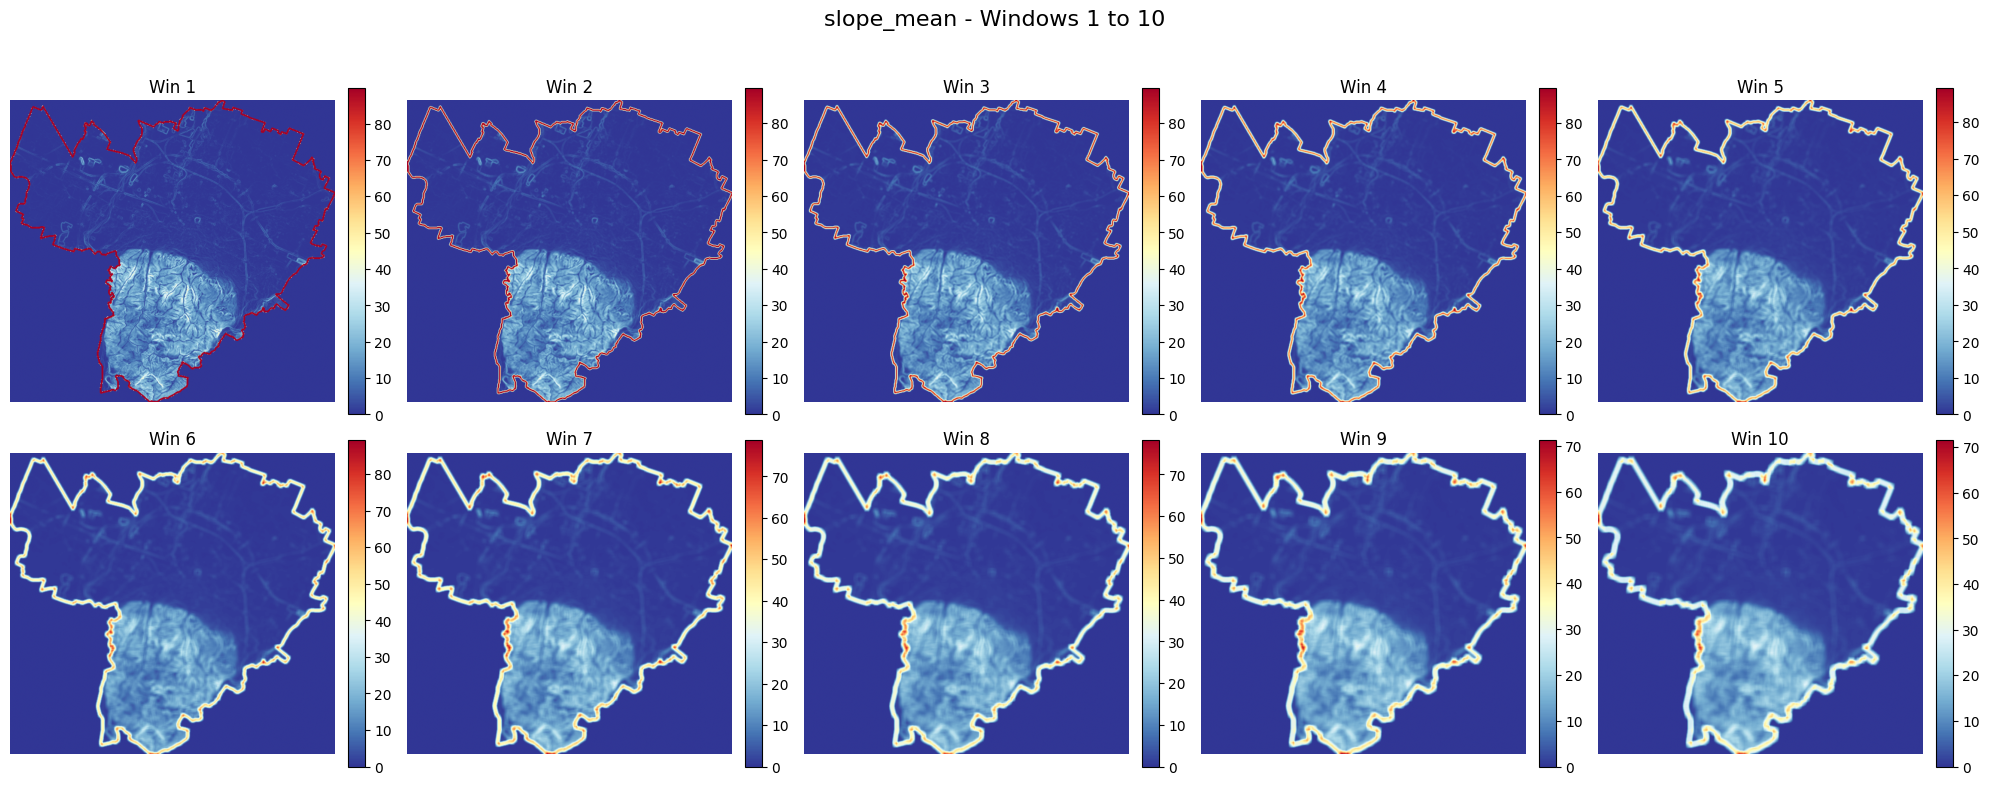

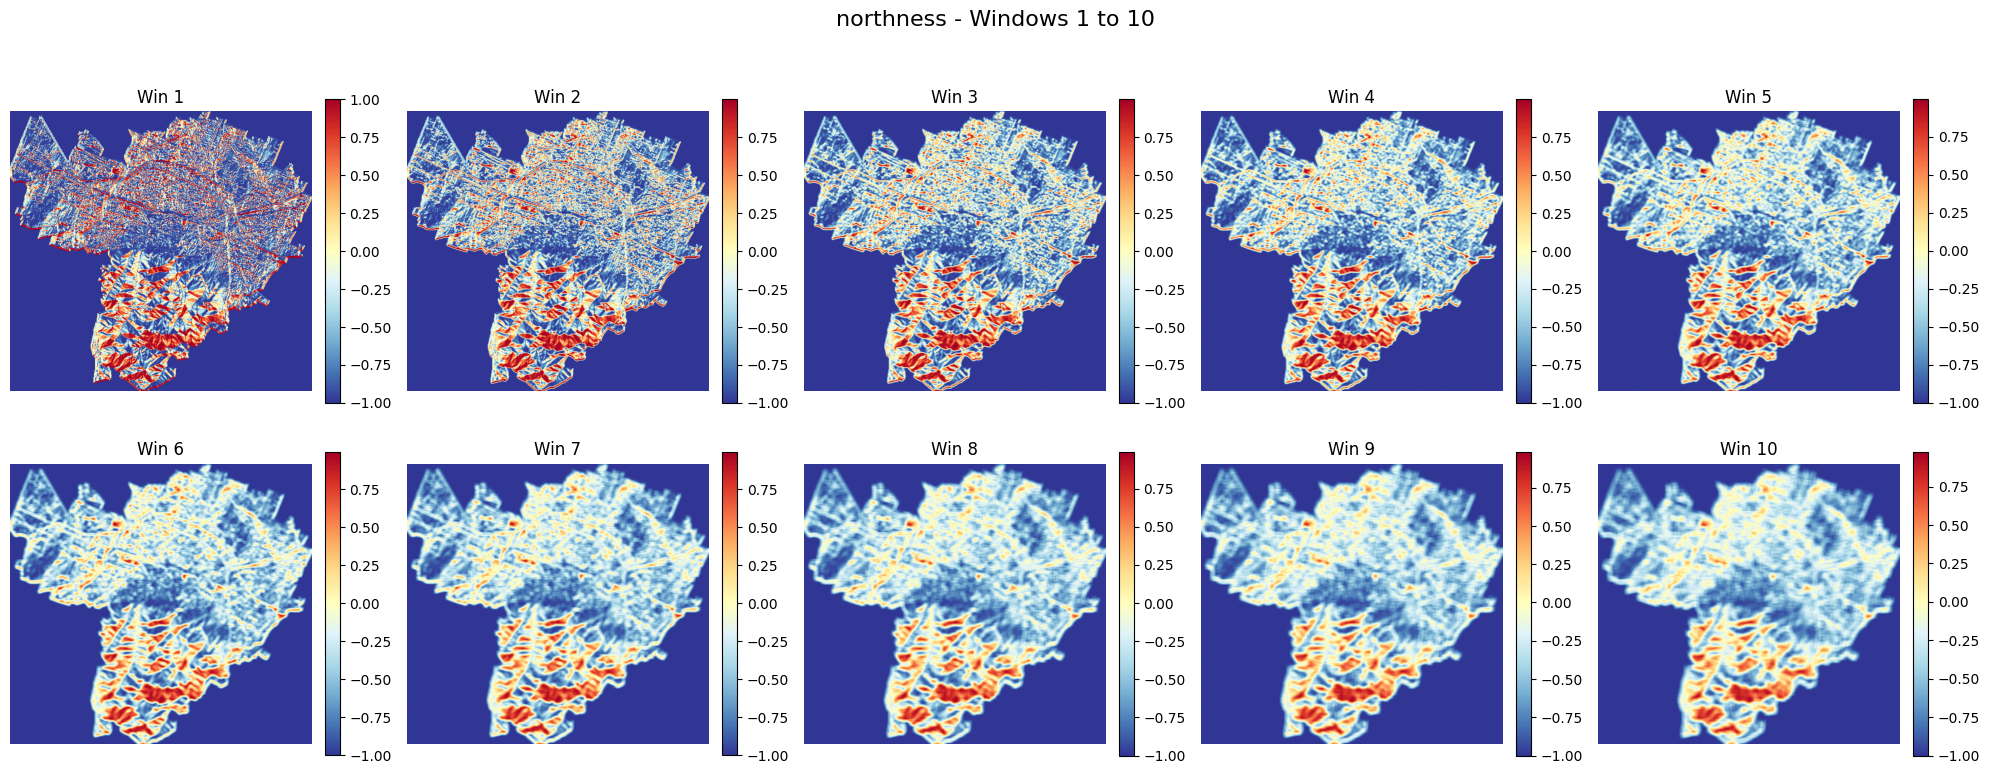

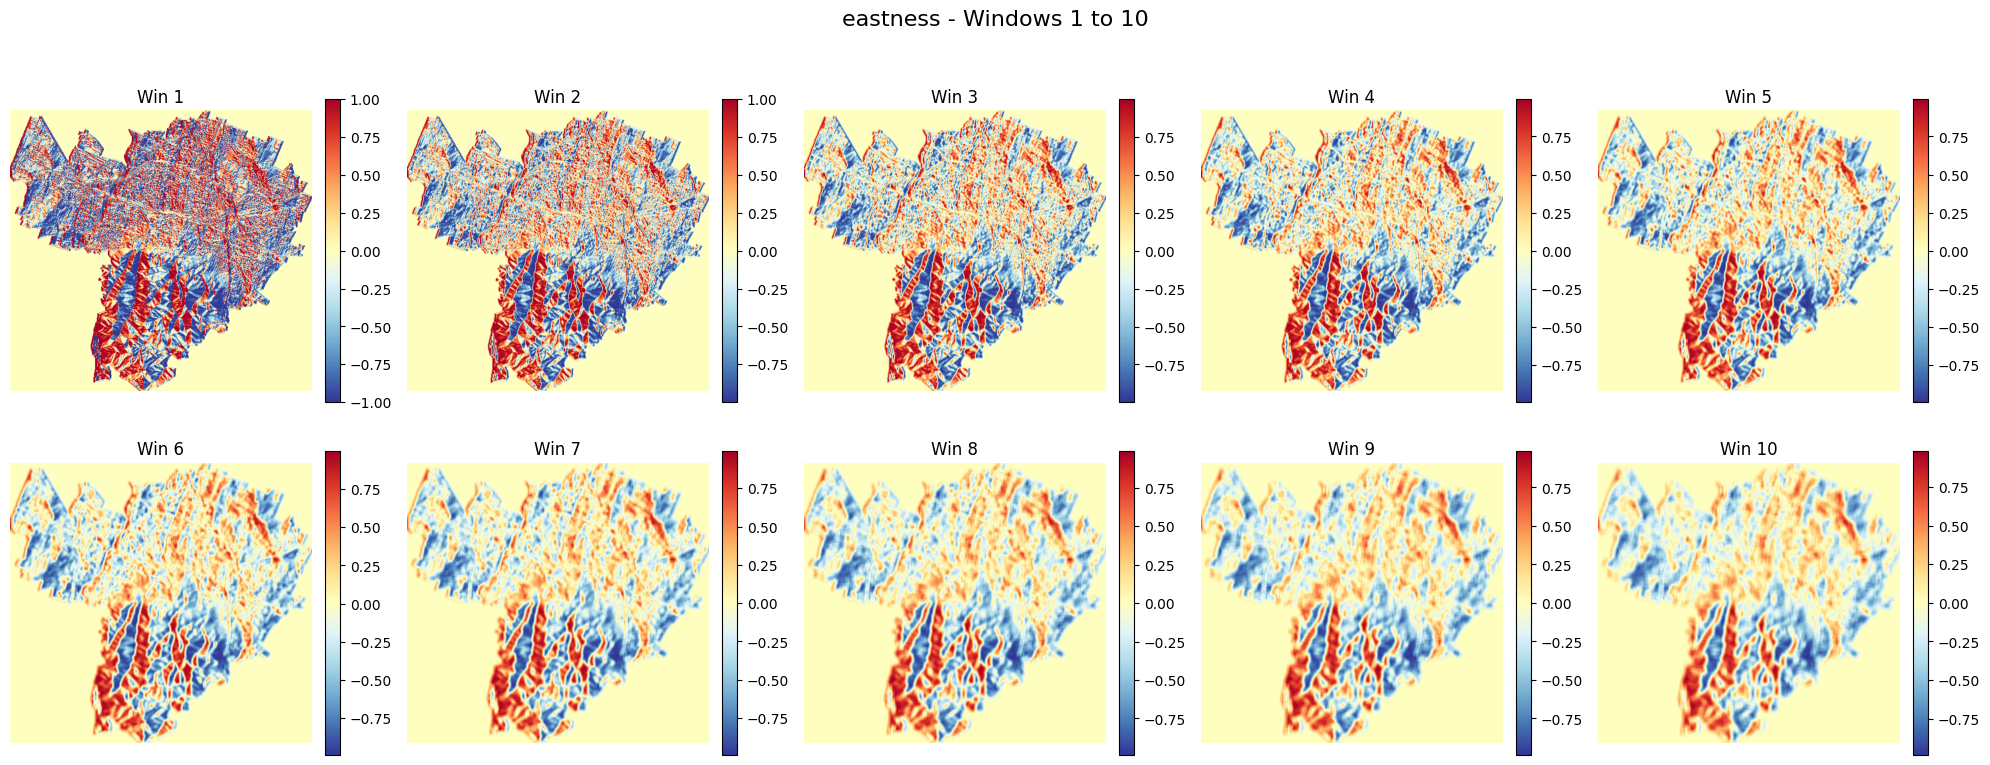

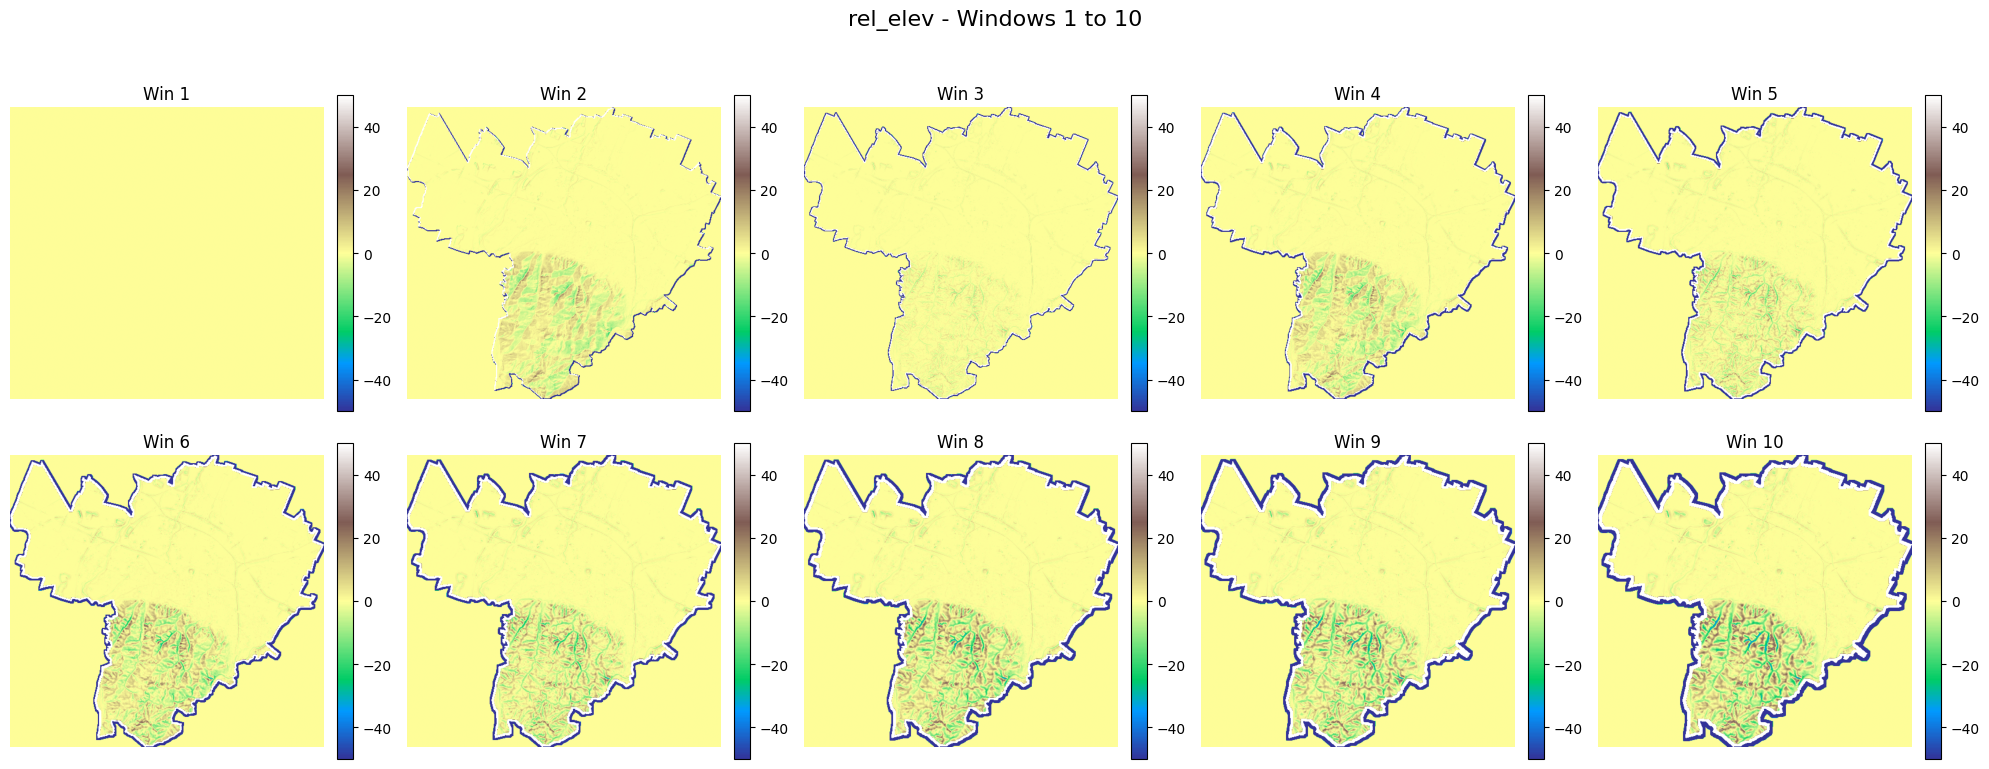

In [40]:
import rasterio
import numpy as np
import os
import matplotlib.pyplot as plt

# --- Paths ---
output_dir = '../../datos-notebooks/3.topography/dtm_pct_30m/'

# --- Windows to visualize ---
window_sizes = range(1, 11)  # 1 a 10

# --- Variables a procesar ---
variables = ["elev_mean", "slope_mean", "northness", "eastness", "rel_elev"]

for var_name in variables:
    var_folder = os.path.join(output_dir, var_name)

    # --- Determine vmin and vmax for Elevation and Rel Elev ---
    if var_name == 'elev_mean':
        vmin, vmax = 0, 500  # ajustar según rango de tu DEM
    elif var_name == 'rel_elev':
        vmin, vmax = -50, 50  # micro-relieve positivo/negativo
    else:
        vmin, vmax = None, None  # auto escala para las demás

    # --- Create subplot grid ---
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()

    for idx, w in enumerate(window_sizes):
        raster_path = os.path.join(var_folder, f"{var_name}_win{w}.tif")
        with rasterio.open(raster_path) as src_var:
            var_data = src_var.read(1).astype(float)

        # --- Plot ---
        im = axes[idx].imshow(var_data, cmap='terrain' if 'elev' in var_name else 'RdYlBu_r',
                              vmin=vmin, vmax=vmax)
        axes[idx].set_title(f"Win {w}")
        axes[idx].axis('off')
        plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)

    plt.suptitle(f"{var_name} - Windows 1 to 10", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


correlations with LST

In [47]:
# --- Paths ---
lst_cropped_path = '../../datos-notebooks/0.LST/LST_cropped_celsius.tif'

# --- general parameters ---
window_sizes = range(1, 81)

# --- Load LST ---
with rasterio.open(lst_cropped_path) as lst:
    lst_crs = lst.crs
    lst_crop = lst.read(1)          
    lst_transform = lst.transform 

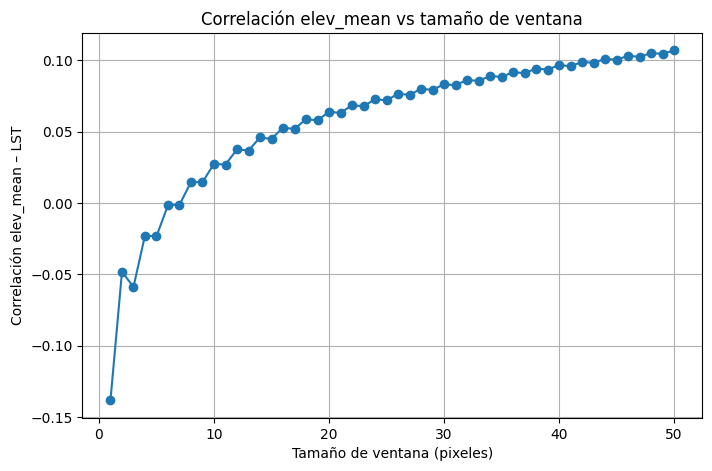

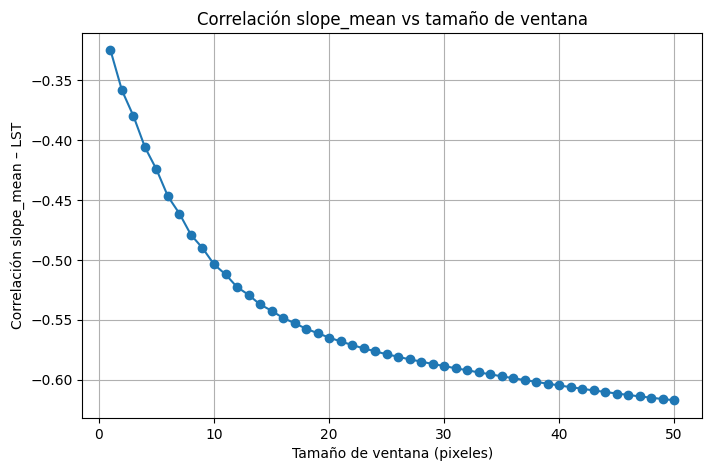

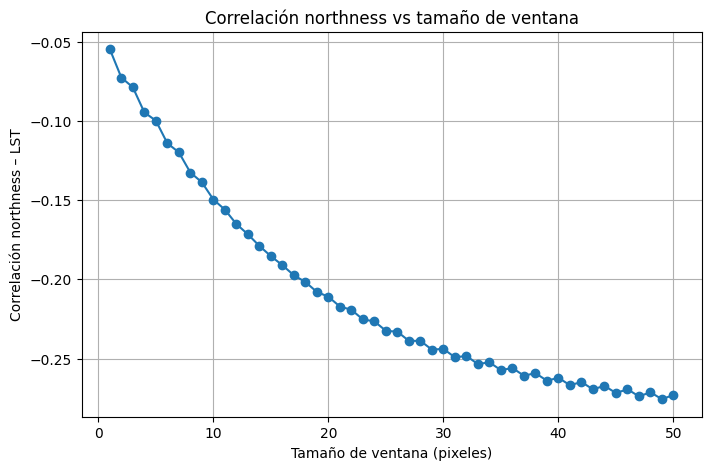

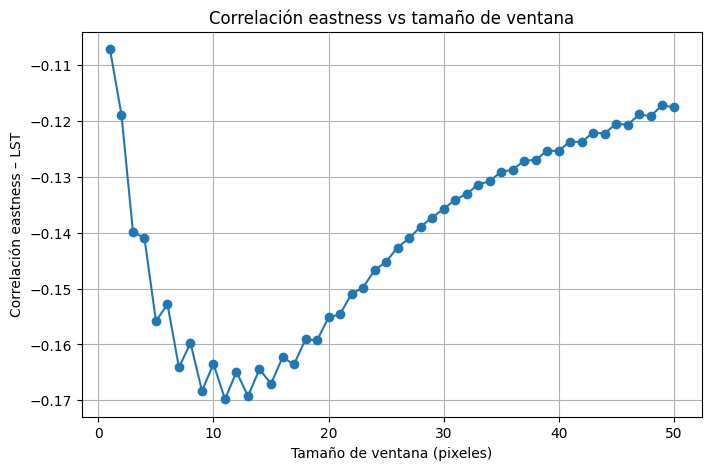

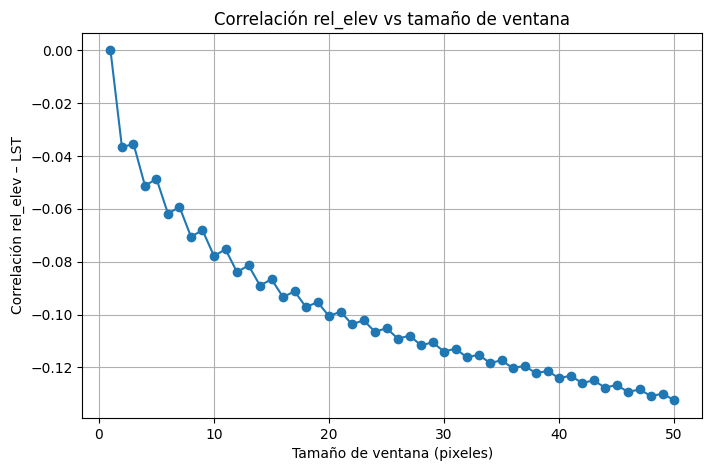

In [59]:
import rasterio
import numpy as np
import os
import matplotlib.pyplot as plt

# --- Paths ---
output_dir = '../../datos-notebooks/3.topography/dtm_pct_30m/'

# --- General parameters ---
window_sizes = range(1, 51)

# --- Variables a procesar ---
variables = ["elev_mean", "slope_mean", "northness", "eastness", "rel_elev"]

for var_name in variables:
    var_folder = os.path.join(output_dir, var_name)
    correlations = []

    for w in window_sizes:
        raster_path = os.path.join(var_folder, f"{var_name}_win{w}.tif")
        with rasterio.open(raster_path) as src_var:
            var_data = src_var.read(1).astype(float)  # read full raster

        # --- Pixel-by-pixel correlation with LST ---
        valid_mask = (~np.isnan(lst_crop))  # only LST valid pixels
        lst_vals = lst_crop[valid_mask]
        var_vals = var_data[valid_mask]

        # --- Handle constant array (std=0) ---
        if np.std(var_vals) == 0 or np.std(lst_vals) == 0:
            corr = 0.0  # or np.nan if prefieres
        else:
            corr = np.corrcoef(var_vals, lst_vals)[0,1]
        correlations.append(corr)

    # --- Plot correlation vs window size ---
    plt.figure(figsize=(8,5))
    plt.plot(window_sizes, correlations, marker='o')
    plt.xlabel("Tamaño de ventana (pixeles)")
    plt.ylabel(f"Correlación {var_name} – LST")
    plt.title(f"Correlación {var_name} vs tamaño de ventana")
    plt.grid(True)
    plt.show()


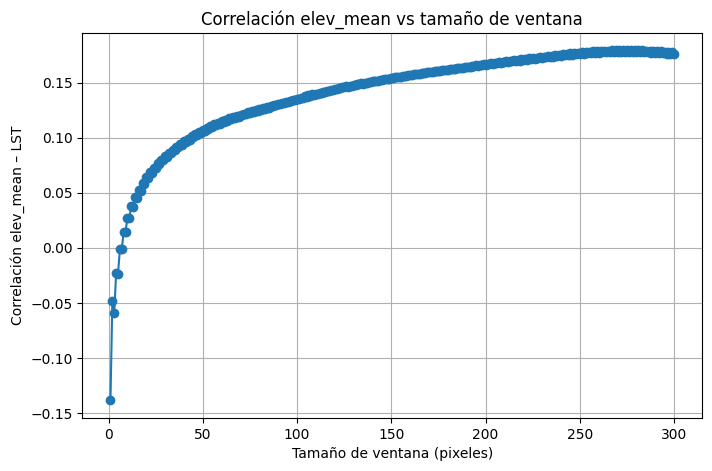

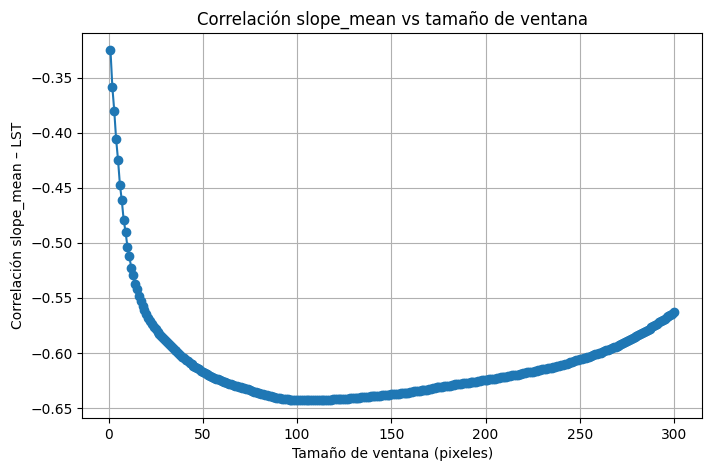

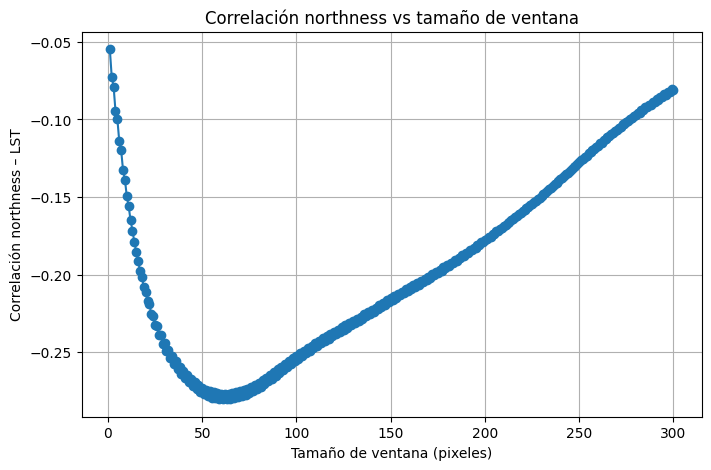

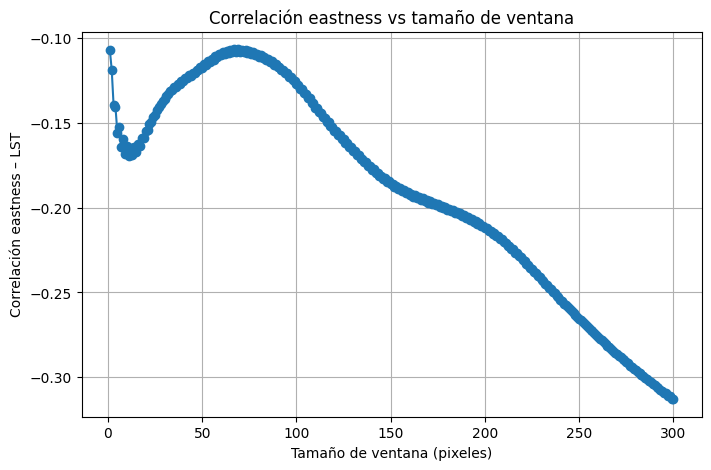

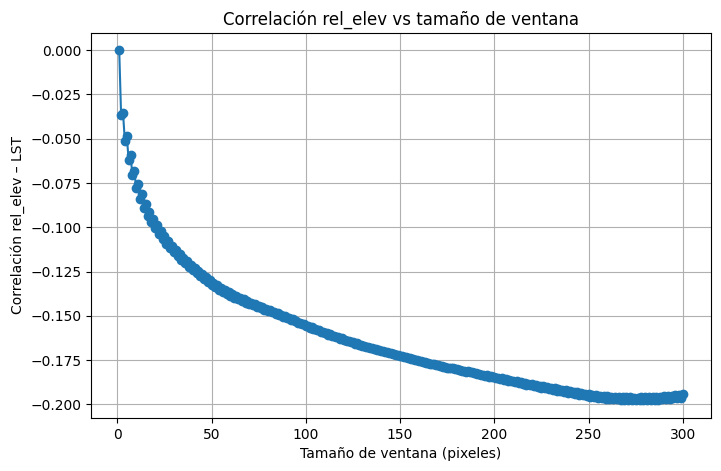

In [60]:
import rasterio
import numpy as np
import os
import matplotlib.pyplot as plt

# --- Paths ---
output_dir = '../../datos-notebooks/3.topography/dtm_pct_30m/'

# --- General parameters ---
window_sizes = range(1, 301)

# --- Variables a procesar ---
variables = ["elev_mean", "slope_mean", "northness", "eastness", "rel_elev"]

for var_name in variables:
    var_folder = os.path.join(output_dir, var_name)
    correlations = []

    for w in window_sizes:
        raster_path = os.path.join(var_folder, f"{var_name}_win{w}.tif")
        with rasterio.open(raster_path) as src_var:
            var_data = src_var.read(1).astype(float)  # read full raster

        # --- Pixel-by-pixel correlation with LST ---
        valid_mask = (~np.isnan(lst_crop))  # only LST valid pixels
        lst_vals = lst_crop[valid_mask]
        var_vals = var_data[valid_mask]

        # --- Handle constant array (std=0) ---
        if np.std(var_vals) == 0 or np.std(lst_vals) == 0:
            corr = 0.0  # or np.nan if prefieres
        else:
            corr = np.corrcoef(var_vals, lst_vals)[0,1]
        correlations.append(corr)

    # --- Plot correlation vs window size ---
    plt.figure(figsize=(8,5))
    plt.plot(window_sizes, correlations, marker='o')
    plt.xlabel("Tamaño de ventana (pixeles)")
    plt.ylabel(f"Correlación {var_name} – LST")
    plt.title(f"Correlación {var_name} vs tamaño de ventana")
    plt.grid(True)
    plt.show()